# 04 — SARIMAX Experiment: Market Only vs Market + AI News

## Objetivo

> **Adicionar features extraídas das notícias melhora a previsão do preço de fechamento do dia?**

Comparamos:

1. **Naive — Previous Close**
2. **SARIMAX — Market Only**
3. **SARIMAX — Market + AI News**

### Target

`preco_fecho`

### Regra temporal

Para prever o fechamento do dia `D`:

- o histórico de `preco_fecho` até `D-1` entra na própria estrutura temporal do SARIMAX;
- as features de mercado são defasadas (`lag_1`);
- as features de notícias correspondem ao dia `D`.

### Avaliação

- MAE
- RMSE
- Directional Accuracy

O teste é **one-step-ahead**: prevemos um dia, observamos o fechamento real e atualizamos o estado do modelo antes de prever o próximo dia.

Isso se aproxima do uso diário da solução.

> Para a POC, assumimos que as notícias agregadas do dia estão disponíveis antes do fechamento. Em uma aplicação real, deve existir cutoff intraday por horário.


## Dependência

Se necessário:

```bash
uv add statsmodels scikit-learn
```


In [22]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX


warnings.filterwarnings("ignore")

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "energy_market_news_daily.csv"
)

print("Dataset:", DATA_PATH)
print("Exists :", DATA_PATH.exists())


Dataset: /Users/hudsonborgo/Desktop/learn projects/Can-AI-listen-to-the-market-/data/features/energy_market_news_daily.csv
Exists : True


## 1. Carregar o dataset integrado

In [23]:
df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
)

df = (
    df
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Rows   : {len(df):,}")
print(
    f"Period : "
    f"{df['date'].min().date()} -> "
    f"{df['date'].max().date()}"
)

df.head()


Rows   : 159
Period : 2026-01-02 -> 2026-08-24


,date,preco_max,preco_min,preco_fecho,quantidade_total,total_ordens_dia,price_change,return,intraday_range,return_next_day,...,score_std,positive_count,neutral_count,negative_count,positive_share,neutral_share,negative_share,signal_ma_3,signal_ma_5,signal_ma_7
0,2026-01-02,330.0,300.00,330.0,29,21,NaN,NaN,30.00,0.054545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-05,367.0,348.00,348.0,146,88,18.0,0.054545,19.00,0.024425,...,0.1091,0.0,12.0,2.0,0.0000,0.8571,0.1429,-0.1006,-0.1006,-0.1006
2,2026-01-06,356.5,339.00,356.5,75,55,8.5,0.024425,17.50,0.110799,...,0.0740,0.0,12.0,1.0,0.0000,0.9231,0.0769,-0.0844,-0.0844,-0.0844
3,2026-01-07,400.0,365.01,396.0,232,161,39.5,0.110799,34.99,-0.080808,...,0.0249,0.0,14.0,0.0,0.0000,1.0000,0.0000,-0.0462,-0.0462,-0.0462
4,2026-01-08,384.0,364.00,364.0,72,53,-32.0,-0.080808,20.00,-0.016484,...,0.0805,1.0,11.0,0.0,0.0833,0.9167,0.0000,0.0230,-0.0079,-0.0079


## 2. Criar features de mercado defasadas

O target é o fechamento do próprio dia.

Portanto, variáveis de mercado do dia `D` não podem ser usadas para prever `preco_fecho_D`.

Usamos somente informações de `D-1`.


In [24]:
df["preco_fecho_lag_1"] = (
    df["preco_fecho"].shift(1)
)

df["return_lag_1"] = (
    df["return"].shift(1)
)

df["quantidade_total_lag_1"] = (
    df["quantidade_total"].shift(1)
)

df["total_ordens_dia_lag_1"] = (
    df["total_ordens_dia"].shift(1)
)

df["intraday_range_lag_1"] = (
    df["intraday_range"].shift(1)
)

df[
    [
        "date",
        "preco_fecho",
        "preco_fecho_lag_1",
        "return_lag_1",
        "quantidade_total_lag_1",
        "total_ordens_dia_lag_1",
        "intraday_range_lag_1",
    ]
].head(10)


,date,preco_fecho,preco_fecho_lag_1,return_lag_1,quantidade_total_lag_1,total_ordens_dia_lag_1,intraday_range_lag_1
0,2026-01-02,330.0,NaN,NaN,NaN,NaN,NaN
1,2026-01-05,348.0,330.0,NaN,29.0,21.0,30.00
2,2026-01-06,356.5,348.0,0.054545,146.0,88.0,19.00
3,2026-01-07,396.0,356.5,0.024425,75.0,55.0,17.50
4,2026-01-08,364.0,396.0,0.110799,232.0,161.0,34.99
5,2026-01-09,358.0,364.0,-0.080808,72.0,53.0,20.00
6,2026-01-12,347.0,358.0,-0.016484,61.0,37.0,25.99
7,2026-01-13,360.0,347.0,-0.030726,75.0,61.0,26.00
8,2026-01-14,353.0,360.0,0.037464,69.0,53.0,13.00
9,2026-01-15,338.0,353.0,-0.019444,47.0,30.0,10.00


## 3. Definir target e features

Para tornar a comparação com Random Forest direta, usamos os mesmos conjuntos de features.

### Market Only

- `preco_fecho_lag_1`
- `return_lag_1`
- `quantidade_total_lag_1`
- `total_ordens_dia_lag_1`
- `intraday_range_lag_1`

### Market + AI News

Adiciona as features de notícias disponíveis no dataset.


In [ ]:
TARGET = "preco_fecho"

market_features = [
    "preco_fecho_lag_1",
    "return_lag_1",
    "quantidade_total_lag_1",
    "total_ordens_dia_lag_1",
    "intraday_range_lag_1",
]

news_candidates = [
    "signal",
#    "avg_relevance",
#    "news_count",
#    "positive_share",
#    "neutral_share",
#    "negative_share",
    "signal_ma_3",
    "signal_ma_5",
    "signal_ma_7",
#  "relevant_news_count",
#   "relevant_signal",
]

news_features = [
    column
    for column in news_candidates
    if column in df.columns
]

all_features = (
    market_features
    + news_features
)

print("Market features:")
for feature in market_features:
    print(" -", feature)

print("\nNews features:")
for feature in news_features:
    print(" -", feature)

print("\nTarget:")
print(" -", TARGET)


Market features:
 - preco_fecho_lag_1
 - return_lag_1
 - quantidade_total_lag_1
 - total_ordens_dia_lag_1
 - intraday_range_lag_1

News features:
 - signal
 - signal_ma_3
 - signal_ma_5
 - signal_ma_7

Target:
 - preco_fecho


## 4. Preparar a amostra

Os modelos `Market Only` e `Market + AI News` usam exatamente as mesmas datas.

Assim, a comparação não é contaminada por diferenças na amostra.


In [26]:
model_df = df[
    ["date", TARGET] + all_features
].copy()

for column in [TARGET] + all_features:
    model_df[column] = pd.to_numeric(
        model_df[column],
        errors="coerce",
    )

model_df = (
    model_df
    .dropna(
        subset=[TARGET] + all_features
    )
    .reset_index(drop=True)
)

print(
    f"Usable observations: "
    f"{len(model_df):,}"
)

print(
    f"Period: "
    f"{model_df['date'].min().date()} -> "
    f"{model_df['date'].max().date()}"
)

model_df.head()


Usable observations: 155
Period: 2026-01-06 -> 2026-08-24


,date,preco_fecho,preco_fecho_lag_1,return_lag_1,quantidade_total_lag_1,total_ordens_dia_lag_1,intraday_range_lag_1,signal,signal_ma_3,signal_ma_5,signal_ma_7
0,2026-01-06,356.5,348.0,0.054545,146.0,88.0,19.00,-0.0681,-0.0844,-0.0844,-0.0844
1,2026-01-07,396.0,356.5,0.024425,75.0,55.0,17.50,0.0300,-0.0462,-0.0462,-0.0462
2,2026-01-08,364.0,396.0,0.110799,232.0,161.0,34.99,0.1072,0.0230,-0.0079,-0.0079
3,2026-01-09,358.0,364.0,-0.080808,72.0,53.0,20.00,0.0281,0.0551,-0.0007,-0.0007
4,2026-01-12,347.0,358.0,-0.016484,61.0,37.0,25.99,0.2413,0.1255,0.0677,0.0396


## 5. Split temporal

Primeiros 80% para treino e últimos 20% para teste.

Não há shuffle.


In [27]:
split_index = int(
    len(model_df) * 0.80
)

train = (
    model_df
    .iloc[:split_index]
    .copy()
)

test = (
    model_df
    .iloc[split_index:]
    .copy()
)

print("=" * 60)
print("TEMPORAL SPLIT")
print("=" * 60)

print(
    f"TRAIN : {len(train)} observations | "
    f"{train['date'].min().date()} -> "
    f"{train['date'].max().date()}"
)

print(
    f"TEST  : {len(test)} observations | "
    f"{test['date'].min().date()} -> "
    f"{test['date'].max().date()}"
)


TEMPORAL SPLIT
TRAIN : 124 observations | 2026-01-06 -> 2026-07-10
TEST  : 31 observations | 2026-07-13 -> 2026-08-24


## 6. Padronizar variáveis exógenas

O SARIMAX pode ficar numericamente instável quando as variáveis exógenas possuem escalas muito diferentes.

Exemplo:

- `return_lag_1`: ~0.01
- `quantidade_total_lag_1`: dezenas/centenas
- `preco_fecho_lag_1`: centenas

Por isso, ajustamos o scaler **somente no treino**.


In [28]:
market_scaler = StandardScaler()

X_train_market = market_scaler.fit_transform(
    train[market_features]
)

X_test_market = market_scaler.transform(
    test[market_features]
)


news_scaler = StandardScaler()

X_train_news = news_scaler.fit_transform(
    train[all_features]
)

X_test_news = news_scaler.transform(
    test[all_features]
)


X_train_market = pd.DataFrame(
    X_train_market,
    columns=market_features,
    index=train.index,
)

X_test_market = pd.DataFrame(
    X_test_market,
    columns=market_features,
    index=test.index,
)

X_train_news = pd.DataFrame(
    X_train_news,
    columns=all_features,
    index=train.index,
)

X_test_news = pd.DataFrame(
    X_test_news,
    columns=all_features,
    index=test.index,
)


## 7. Função de avaliação

Directional Accuracy compara se o modelo acertou a direção do preço em relação ao fechamento anterior.


In [29]:
def evaluate_model(
    y_true,
    y_pred,
    previous_close,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    previous_close = np.asarray(
        previous_close,
        dtype=float,
    )

    mae = mean_absolute_error(
        y_true,
        y_pred,
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred,
        )
    )

    actual_direction = np.sign(
        y_true - previous_close
    )

    predicted_direction = np.sign(
        y_pred - previous_close
    )

    directional_accuracy = np.mean(
        actual_direction
        == predicted_direction
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": (
            directional_accuracy
        ),
    }


## 8. Baseline ingênuo — fechamento anterior

A referência mais simples é:

> previsão de hoje = fechamento de ontem


In [30]:
y_test = test[TARGET]

previous_close_test = test[
    "preco_fecho_lag_1"
]

naive_pred = (
    previous_close_test
    .to_numpy()
)

naive_metrics = evaluate_model(
    y_test,
    naive_pred,
    previous_close_test,
)

naive_metrics


{'MAE': 5.544516129032257,
 'RMSE': np.float64(8.701139339560745),
 'Directional Accuracy': np.float64(0.03225806451612903)}

## 9. Configuração SARIMAX

Usaremos inicialmente:

`order = (1, 1, 1)`

Interpretação:

- AR(1): dependência do histórico recente;
- I(1): diferenciação para lidar com nível de preço não estacionário;
- MA(1): componente de erro recente.

Não estamos fazendo tuning agressivo nesta POC.


In [31]:
SARIMAX_ORDER = (
    1,
    1,
    1,
)

print(
    "SARIMAX order:",
    SARIMAX_ORDER,
)


SARIMAX order: (1, 1, 1)


## 10. Função de previsão one-step-ahead

Fluxo:

```text
Treino
  ↓
prevê primeiro dia do teste
  ↓
observa fechamento real
  ↓
atualiza estado
  ↓
prevê próximo dia
  ↓
...
```

Isso evita fazer uma previsão multi-step longa sem incorporar os preços reais que surgem ao longo do tempo.


In [32]:
def sarimax_walk_forward(
    y_train,
    X_train,
    y_test,
    X_test,
    order=(1, 1, 1),
):
    model = SARIMAX(
        endog=y_train,
        exog=X_train,
        order=order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    fitted = model.fit(
        disp=False,
        maxiter=300,
    )

    predictions = []

    state = fitted

    for position in range(
        len(y_test)
    ):
        current_exog = (
            X_test
            .iloc[[position]]
        )

        forecast = state.get_forecast(
            steps=1,
            exog=current_exog,
        )

        prediction = float(
            forecast.predicted_mean.iloc[0]
        )

        predictions.append(
            prediction
        )

        actual_value = float(
            y_test.iloc[position]
        )

        state = state.append(
            endog=[actual_value],
            exog=current_exog,
            refit=False,
        )

    return np.array(
        predictions
    )


## 11. Modelo 1 — SARIMAX Market Only

In [33]:
pred_market = sarimax_walk_forward(
    y_train=train[TARGET],
    X_train=X_train_market,
    y_test=test[TARGET],
    X_test=X_test_market,
    order=SARIMAX_ORDER,
)

market_metrics = evaluate_model(
    y_test,
    pred_market,
    previous_close_test,
)

market_metrics


{'MAE': 5.448631981327307,
 'RMSE': np.float64(8.969340125046878),
 'Directional Accuracy': np.float64(0.5161290322580645)}

## 12. Modelo 2 — SARIMAX Market + AI News

In [34]:
pred_news = sarimax_walk_forward(
    y_train=train[TARGET],
    X_train=X_train_news,
    y_test=test[TARGET],
    X_test=X_test_news,
    order=SARIMAX_ORDER,
)

news_metrics = evaluate_model(
    y_test,
    pred_news,
    previous_close_test,
)

news_metrics


{'MAE': 6.681566827247548,
 'RMSE': np.float64(10.094097513247654),
 'Directional Accuracy': np.float64(0.5806451612903226)}

## 13. Comparação principal

Menor MAE/RMSE é melhor.

Maior Directional Accuracy é melhor.


In [35]:
results = pd.DataFrame(
    [
        {
            "Model": (
                "Naive: Previous Close"
            ),
            **naive_metrics,
        },
        {
            "Model": (
                "SARIMAX: Market Only"
            ),
            **market_metrics,
        },
        {
            "Model": (
                "SARIMAX: Market + AI News"
            ),
            **news_metrics,
        },
    ]
).set_index("Model")

results


,MAE,RMSE,Directional Accuracy
Model,,,
Naive: Previous Close,5.544516,8.701139,0.032258
SARIMAX: Market Only,5.448632,8.969340,0.516129
SARIMAX: Market + AI News,6.681567,10.094098,0.580645


## 14. Ganho incremental das notícias

In [36]:
mae_improvement = (
    (
        market_metrics["MAE"]
        - news_metrics["MAE"]
    )
    / market_metrics["MAE"]
)

rmse_improvement = (
    (
        market_metrics["RMSE"]
        - news_metrics["RMSE"]
    )
    / market_metrics["RMSE"]
)

direction_improvement = (
    news_metrics[
        "Directional Accuracy"
    ]
    - market_metrics[
        "Directional Accuracy"
    ]
)

print("=" * 70)
print(
    "  SARIMAX MARKET ONLY "
    "vs MARKET + AI NEWS"
)
print("=" * 70)

print(
    f"MAE improvement       : "
    f"{mae_improvement:+.1%}"
)

print(
    f"RMSE improvement      : "
    f"{rmse_improvement:+.1%}"
)

print(
    f"Directional accuracy  : "
    f"{market_metrics['Directional Accuracy']:.1%}"
    f" -> "
    f"{news_metrics['Directional Accuracy']:.1%}"
)

print(
    f"Direction improvement : "
    f"{direction_improvement:+.1%} pts"
)


  SARIMAX MARKET ONLY vs MARKET + AI NEWS
MAE improvement       : -22.6%
RMSE improvement      : -12.5%
Directional accuracy  : 51.6% -> 58.1%
Direction improvement : +6.5% pts


## 15. Visual principal para apresentação

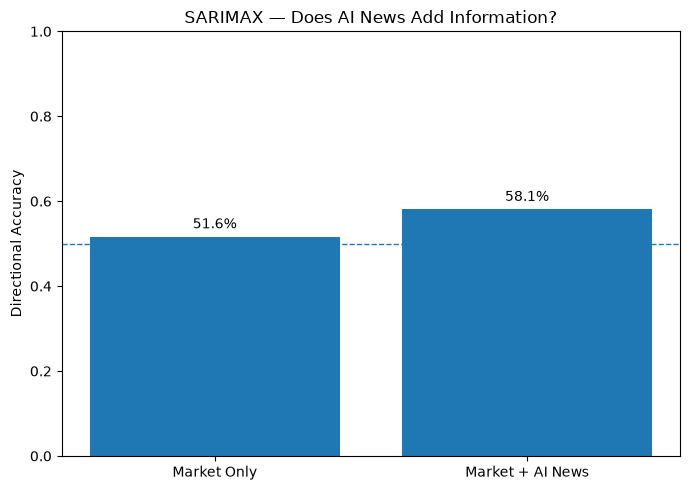

In [37]:
direction_results = pd.DataFrame(
    {
        "Model": [
            "Market Only",
            "Market + AI News",
        ],
        "Directional Accuracy": [
            market_metrics[
                "Directional Accuracy"
            ],
            news_metrics[
                "Directional Accuracy"
            ],
        ],
    }
)

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.bar(
    direction_results["Model"],
    direction_results[
        "Directional Accuracy"
    ],
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
)

ax.set_ylim(
    0,
    1,
)

ax.set_ylabel(
    "Directional Accuracy"
)

ax.set_title(
    "SARIMAX — Does AI News Add Information?"
)

for index, value in enumerate(
    direction_results[
        "Directional Accuracy"
    ]
):
    ax.text(
        index,
        value + 0.02,
        f"{value:.1%}",
        ha="center",
    )

plt.tight_layout()
plt.show()


## 16. Preço real vs previsões

Comparação visual fora da amostra.


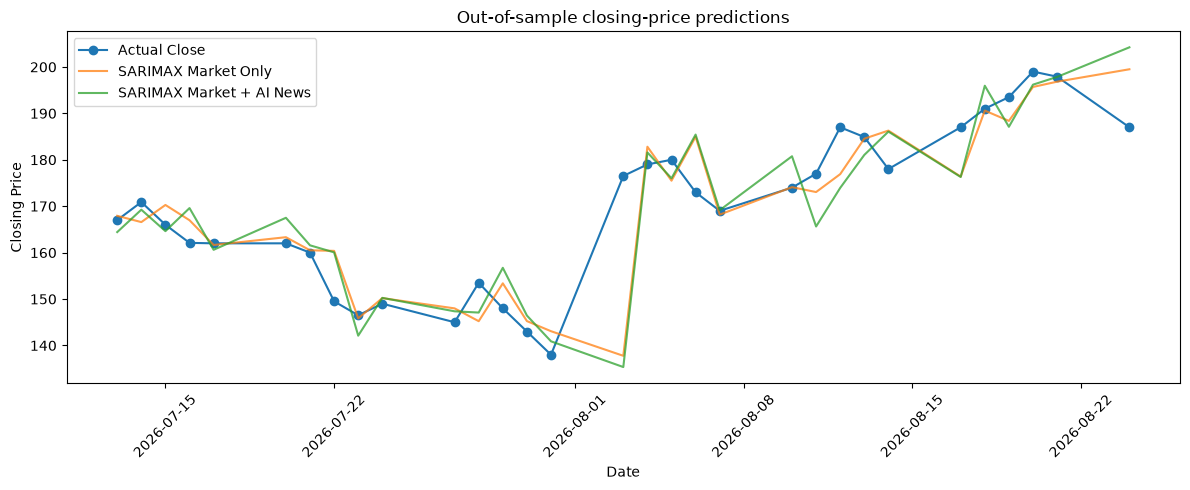

In [38]:
predictions = pd.DataFrame(
    {
        "date": test["date"].values,
        "actual": y_test.values,
        "previous_close": (
            previous_close_test.values
        ),
        "market_only": pred_market,
        "market_plus_news": pred_news,
    }
)

fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.plot(
    predictions["date"],
    predictions["actual"],
    label="Actual Close",
    marker="o",
)

ax.plot(
    predictions["date"],
    predictions["market_only"],
    label="SARIMAX Market Only",
    alpha=0.75,
)

ax.plot(
    predictions["date"],
    predictions["market_plus_news"],
    label="SARIMAX Market + AI News",
    alpha=0.75,
)

ax.set_title(
    "Out-of-sample closing-price predictions"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Closing Price"
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()
